✅ CSV 로드: 2836872
✅ datetime 컬럼: departure_datetime
✅ is_delay 분포:
 0    2354459
1     482413
Name: is_delay, dtype: int64
✅ 양성(1) 비율: 0.1701
Train: 2269498 Test: 567374
Test 양성(1) 비율: 0.2578
✅ num_cols: ['dep_hour', 'dep_weekday', 'is_weekend', 'dep_minute']
✅ cat_cols: ['항공사', '출발지', 'arrival_code', 'flight_type']
✅ X_cols: ['dep_hour', 'dep_weekday', 'is_weekend', 'dep_minute', '항공사', '출발지', 'arrival_code', 'flight_type']
✅ train pos/neg: 336168 1933330 scale_pos_weight: 5.7511
✅ 비교 모델: ['Logistic', 'LinearSVC(Calibrated)', 'XGBoost', 'LightGBM']

TRAIN: Logistic

TRAIN: LinearSVC(Calibrated)

TRAIN: XGBoost

TRAIN: LightGBM
[LightGBM] [Info] Number of positive: 336168, number of negative: 1933330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 387
[LightGBM] [Info] Number of dat

C:\Users\Admin\anaconda3\envs\4vector\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ prob 수집 완료: ['Logistic', 'LinearSVC(Calibrated)', 'XGBoost', 'LightGBM']


,model,thr,ROC_AUC,PR_AUC,ACC,PREC,RECALL,F1
0,LightGBM,0.6,0.739570,0.488861,0.732129,0.479100,0.449711,0.463941
1,XGBoost,0.6,0.710559,0.449718,0.717255,0.443759,0.382447,0.410828
2,LinearSVC(Calibrated),0.6,0.661096,0.373398,0.742242,0.000000,0.000000,0.000000
3,Logistic,0.6,0.658395,0.370311,0.700018,0.393775,0.303627,0.342875


✅ Best(정렬 기준: PR_AUC → F1 → ROC_AUC): LightGBM


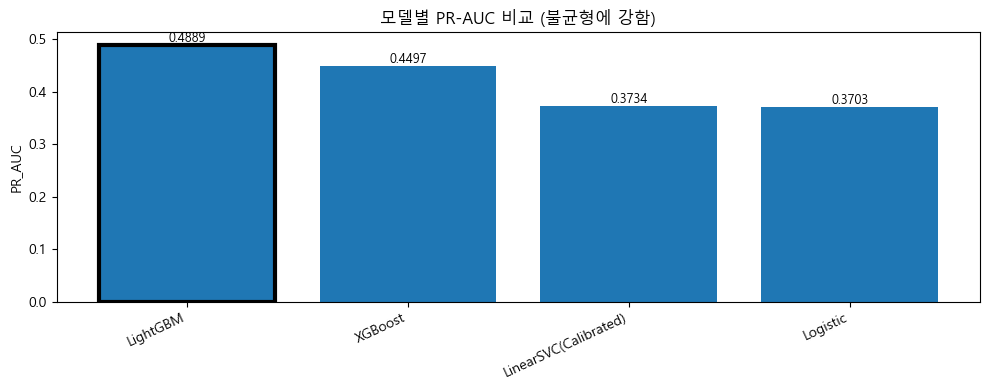

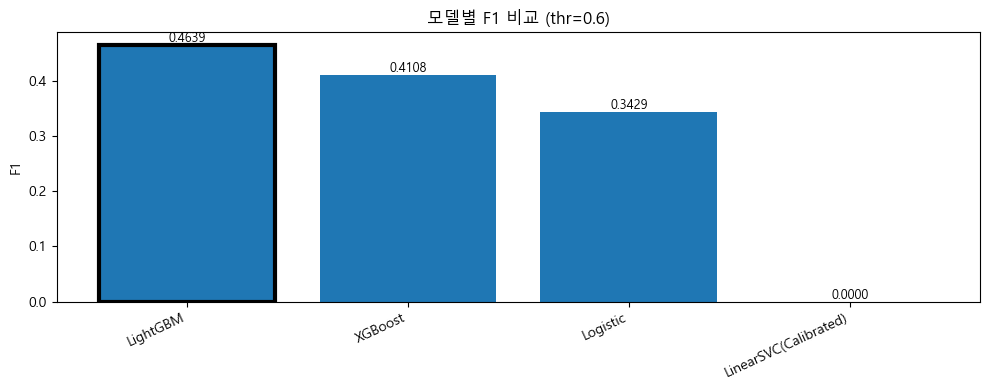

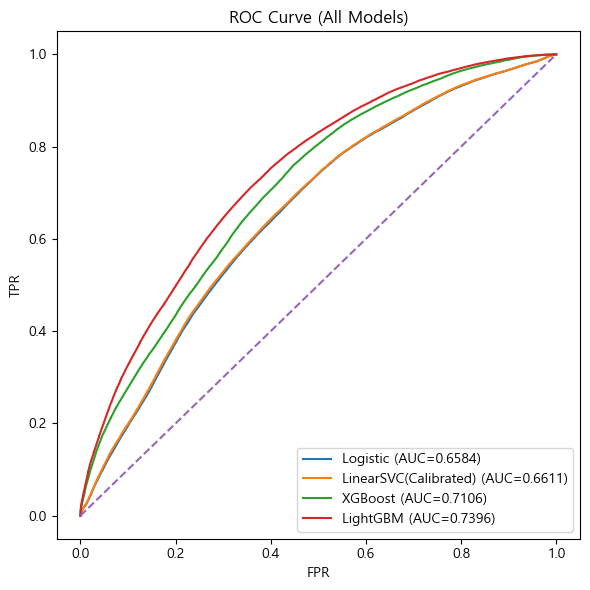

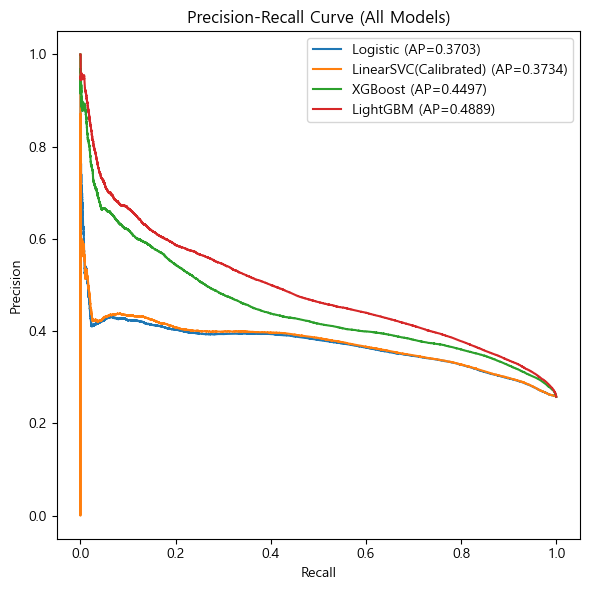

✅ Threshold sweep 대상: ['LightGBM', 'XGBoost', 'LinearSVC(Calibrated)']


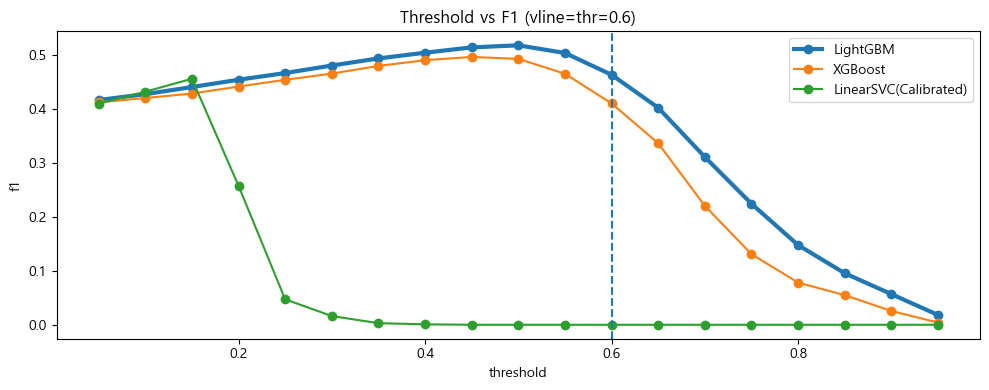

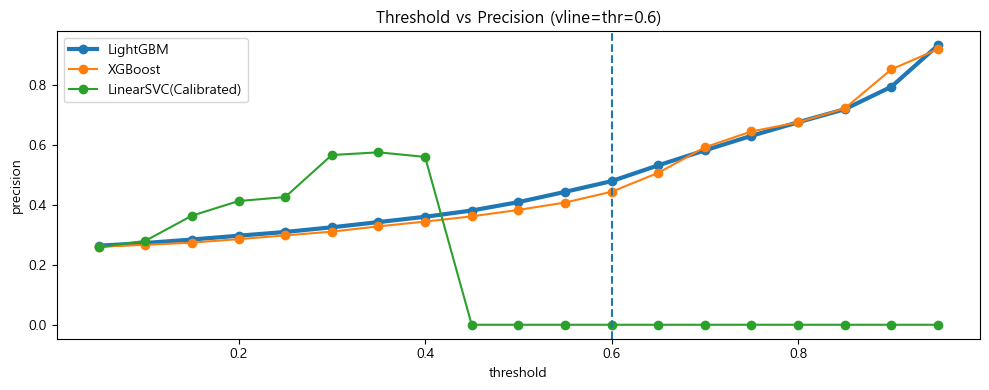

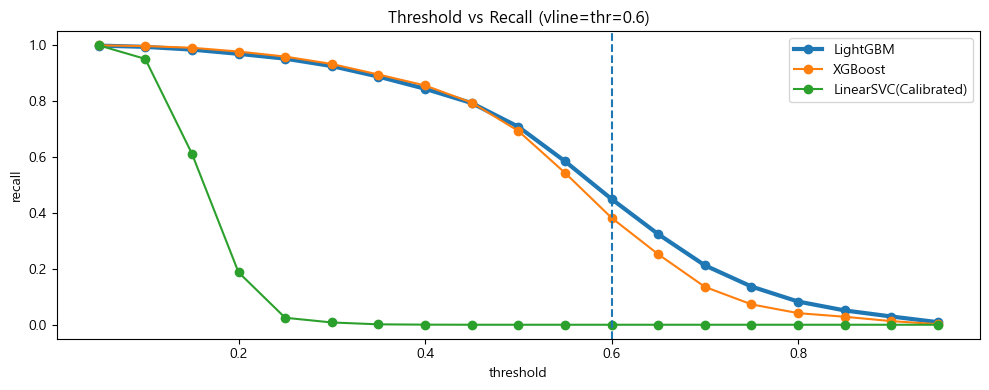

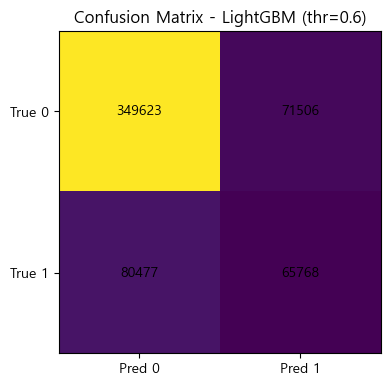

              precision    recall  f1-score   support

           0     0.8129    0.8302    0.8215    421129
           1     0.4791    0.4497    0.4639    146245

    accuracy                         0.7321    567374
   macro avg     0.6460    0.6400    0.6427    567374
weighted avg     0.7269    0.7321    0.7293    567374



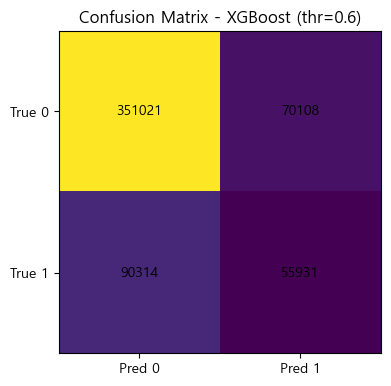

              precision    recall  f1-score   support

           0     0.7954    0.8335    0.8140    421129
           1     0.4438    0.3824    0.4108    146245

    accuracy                         0.7173    567374
   macro avg     0.6196    0.6080    0.6124    567374
weighted avg     0.7047    0.7173    0.7101    567374



In [1]:
# =====================================================
# ✅ 이진분류 4개 모델 비교 (한글 컬럼/시간기준 split/원핫 통일)
# - LogisticRegression / LinearSVC+Calibrated / XGBoost / LightGBM
# - 평가: PR-AUC, ROC-AUC, 그리고 THR 기준 ACC/P/R/F1
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

# (선택) xgboost
try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except Exception as e:
    _HAS_XGB = False
    print("⚠️ xgboost import 실패:", e)
    print("   필요하면: pip install xgboost")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# =========================
# ✅ 경로/설정
# =========================
csv_path = r"new_flight_analysis_summary.csv"   # ← 너 파일 경로로 변경
THR = 0.6                                            # ← 임계값(원하면 0.6 등으로 변경)
THS = np.unique(np.r_[np.linspace(0.05, 0.95, 19), THR])
THS.sort()


# =====================================================
# 1) 데이터 로드 + datetime/파생변수 + 타깃(is_delay)
# =====================================================
df = pd.read_csv(csv_path)
print("✅ CSV 로드:", len(df))

# 1) datetime 컬럼 자동 선택
if "departure_datetime" in df.columns:
    dt_col = "departure_datetime"
elif "일시" in df.columns:
    dt_col = "일시"
elif "flight_date" in df.columns:
    dt_col = "flight_date"
else:
    raise KeyError("❌ 날짜/시간 컬럼을 못 찾음 (departure_datetime / 일시 / flight_date 중 없음)")

df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
df = df[df[dt_col].notna()].copy()

# 2) 시간 파생 (날씨X)
df["dep_hour"] = df["departure_datetime"].dt.hour
df["dep_minute"] = df["departure_datetime"].dt.minute   # ✅ 분 추가
df["dep_weekday"] = df["departure_datetime"].dt.weekday
df["is_weekend"] = df["dep_weekday"].isin([5, 6]).astype(int)

# 3) arrival_code 코드화(있으면)
if "arrival_code" in df.columns:
    df["arrival_code"] = pd.to_numeric(df["arrival_code"], errors="coerce").fillna(-1).astype(int)
elif "도착지" in df.columns:
    tmp = pd.to_numeric(df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        df["arrival_code"] = tmp.fillna(-1).astype(int)
    else:
        df["arrival_code"] = df["도착지"].astype("category").cat.codes.astype(int)
else:
    # arrival_code 없어도 진행은 가능(단, cat_cols에서 빠짐)
    pass

# 4) 타깃 is_delay 생성/확인
if "is_delay" in df.columns:
    df["is_delay"] = pd.to_numeric(df["is_delay"], errors="coerce").fillna(0).astype(int)
else:
    if "상태" in df.columns:
        # 기본: 지연만 1 (원하면 결항/회항도 1로 확장 가능)
        df["is_delay"] = df["상태"].astype(str).isin(["지연", "결항", "회항"]).astype(int)
    elif "status" in df.columns:
        df["is_delay"] = df["status"].astype(str).str.lower().isin(["delay", "delayed", "cancel", "diverted"]).astype(int)
    else:
        raise KeyError("❌ is_delay도 없고, '상태'/'status'도 없음 (타깃 생성 불가)")

print("✅ datetime 컬럼:", dt_col)
print("✅ is_delay 분포:\n", df["is_delay"].value_counts().sort_index())
print("✅ 양성(1) 비율:", df["is_delay"].mean().round(4))


# =====================================================
# 2) 시간 기준 Train/Test split (80/20)
# =====================================================
df = df.sort_values(dt_col)
split_dt = df[dt_col].quantile(0.8)

train_df = df[df[dt_col] <= split_dt].copy()
test_df  = df[df[dt_col] >  split_dt].copy()

print("Train:", len(train_df), "Test:", len(test_df))
print("Test 양성(1) 비율:", test_df["is_delay"].mean().round(4))


# =====================================================
# 3) 피처 정의 + 전처리(원핫)  ✅ 날씨 제외
# =====================================================
cat_cols = ["항공사", "출발지", "arrival_code", "flight_type"]
cat_cols = [c for c in cat_cols if c in df.columns]

num_cols = ["dep_hour", "dep_weekday", "is_weekend","dep_minute"]
num_cols = [c for c in num_cols if c in df.columns]

X_cols = num_cols + cat_cols
print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)

X_train = train_df[X_cols]
y_train = train_df["is_delay"].values

X_test = test_df[X_cols]
y_test = test_df["is_delay"].values

# OneHotEncoder 버전 호환
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols)
    ],
    remainder="drop"
)

# 불균형 보정용 pos_weight (tree 모델에 사용)
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / max(pos, 1))
print("✅ train pos/neg:", pos, neg, "scale_pos_weight:", round(scale_pos_weight, 4))


# =====================================================
# 4) 모델 정의
# =====================================================
models = {}

# 1) Logistic
models["Logistic"] = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# 2) Linear (LinearSVC + Calibration -> predict_proba 확보)
base_linear = Pipeline([
    ("prep", preprocessor),
    ("clf", LinearSVC(class_weight="balanced", random_state=42))
])
models["LinearSVC(Calibrated)"] = CalibratedClassifierCV(base_linear, cv=3, method="sigmoid")

# 3) XGBoost
if _HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=700,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            min_child_weight=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            tree_method="hist"
        ))
    ])
else:
    print("⚠️ XGBoost 스킵 (xgboost 미설치)")

# 4) LightGBM
models["LightGBM"] = Pipeline([
    ("prep", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=900,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

print("✅ 비교 모델:", list(models.keys()))


# =====================================================
# 5) 학습 + 예측확률(prob) 수집
# =====================================================
probs = {}
for name, model in models.items():
    print("\n==============================")
    print("TRAIN:", name)
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        p = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    probs[name] = np.asarray(p).reshape(-1)

print("\n✅ prob 수집 완료:", list(probs.keys()))


# =====================================================
# 6) 리더보드(ROC/PR + THR 기준 P/R/F1/ACC)
# =====================================================
def metrics_at_thr(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "ACC": accuracy_score(y_true, pred),
        "PREC": precision_score(y_true, pred, zero_division=0),
        "RECALL": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
    }

rows = []
for name, p in probs.items():
    m = metrics_at_thr(y_test, p, THR)
    rows.append([name, THR, m["ROC_AUC"], m["PR_AUC"], m["ACC"], m["PREC"], m["RECALL"], m["F1"]])

leaderboard = pd.DataFrame(
    rows, columns=["model","thr","ROC_AUC","PR_AUC","ACC","PREC","RECALL","F1"]
).sort_values(["PR_AUC","F1","ROC_AUC"], ascending=False).reset_index(drop=True)

display(leaderboard)

best = leaderboard.loc[0, "model"]
print("✅ Best(정렬 기준: PR_AUC → F1 → ROC_AUC):", best)


# =====================================================
# 7) (시각화 1) PR-AUC / F1@THR 랭킹 바 (값 라벨 포함)
# =====================================================
def bar_rank(df, metric, higher_is_better=True, title=None):
    d = df.sort_values(metric, ascending=not higher_is_better)
    best_model = d.iloc[0]["model"]

    plt.figure(figsize=(10,4))
    bars = plt.bar(d["model"], d[metric])
    for b, m, v in zip(bars, d["model"], d[metric].values):
        if m == best_model:
            b.set_edgecolor("black")
            b.set_linewidth(3)
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.4f}",
                 ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=25, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric} 비교 (Best={best_model})")
    plt.tight_layout()
    plt.show()

bar_rank(leaderboard, "PR_AUC", True, "모델별 PR-AUC 비교 (불균형에 강함)")
bar_rank(leaderboard, "F1", True, f"모델별 F1 비교 (thr={THR})")


# =====================================================
# 8) (시각화 2) ROC / PR Curve 오버레이
# =====================================================
plt.figure(figsize=(6,6))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
for name, p in probs.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (All Models)")
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# 9) (시각화 3) Threshold sweep: F1 / Precision / Recall (Top 3만)
# =====================================================
top_k = min(3, len(leaderboard))
top_models = leaderboard["model"].head(top_k).tolist()
print("✅ Threshold sweep 대상:", top_models)

def sweep(y_true, prob, ths):
    out=[]
    for t in ths:
        pred=(prob>=t).astype(int)
        out.append([t,
                    accuracy_score(y_true,pred),
                    precision_score(y_true,pred,zero_division=0),
                    recall_score(y_true,pred,zero_division=0),
                    f1_score(y_true,pred,zero_division=0)])
    return pd.DataFrame(out, columns=["thr","acc","precision","recall","f1"])

sweeps = {m: sweep(y_test, probs[m], THS) for m in top_models}

for metric, title in [("f1","Threshold vs F1"), ("precision","Threshold vs Precision"), ("recall","Threshold vs Recall")]:
    plt.figure(figsize=(10,4))
    for m in top_models:
        dfm = sweeps[m]
        plt.plot(dfm["thr"], dfm[metric], marker="o", label=m, linewidth=3 if m==best else 1.5)
    plt.axvline(THR, linestyle="--")
    plt.xlabel("threshold")
    plt.ylabel(metric)
    plt.title(f"{title} (vline=thr={THR})")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =====================================================
# 10) Confusion Matrix + Report (thr=THR) (Top 2만)
# =====================================================
show_k = min(2, len(leaderboard))
show_models = leaderboard["model"].head(show_k).tolist()

def plot_cm(y_true, prob, thr, title):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], ["Pred 0","Pred 1"])
    plt.yticks([0,1], ["True 0","True 1"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, pred, digits=4))

for m in show_models:
    plot_cm(y_test, probs[m], THR, f"Confusion Matrix - {m} (thr={THR})")
